In [27]:
import random
import numpy as np
import matplotlib.pyplot as plt
from micrograd.engine import Value
from micrograd.nn import Neuron,Layer,MLP
%matplotlib inline
np.random.seed(1337)
random.seed(1337)

随机种子固定随机值让结果可复现
使用scikit-learn 的 make_moons函数来生成一个数据集
为了简化后续步骤中的损失计算，我们将类别0和1替换为-1和1

[-0.81882941  0.05879006]


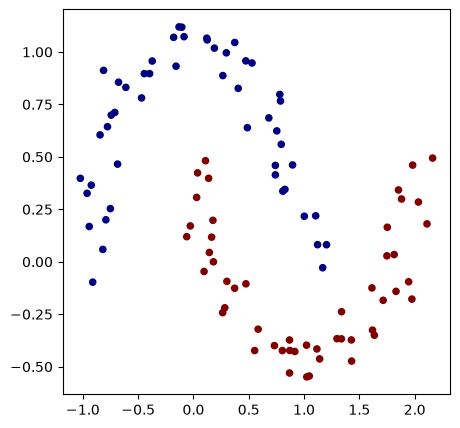

In [28]:
from sklearn.datasets import make_moons,make_blobs
X,y = make_moons(n_samples=100,noise=0.1)
print(X[1])
y=y*2-1    # -1->1

plt.figure(figsize=(5,5))
plt.scatter(X[:,0],X[:,1],c=y,s=20,cmap='jet')

moons 月亮型数据 适合测试非线性分类
(n,noise,random_state)  random_state内部调用的就是np.random之前已经固定过种子了
make_moons(n_samples=100, noise=0.1)：生成 100 个点，加入标准差 0.1 的高斯噪声，让点不完全沿月牙线排列，稍微散开一点，更真实。

返回值 X, y：

X：形状 (100, 2) 的数组，100 个点的 (x₁, x₂) 坐标
y：形状 (100,) 的数组，每个点的标签（0 或 1，表示属于哪个月牙）
这就是一个二分类任务——目标是训练一个神经网络，学会根据坐标 (x₁, x₂) 判断一个点属于上弦月还是下弦月。这也是 micrograd 教程里的经典 demo，用来展示 MLP 能学到非线性决策边界。


In [29]:
model = MLP(2,[16,16,1])
print(model)
print("num of  parametres:",len(model.parameters()))


MLP of [Layer of [ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2)], Layer of [ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16)], Layer of [LinearNeuron(16)]]
num of  parametres: 337


SGD随机梯度下降
在大小为N的数据集上应用梯度下降算法，理论上需要每次在每次迭代之前计算每个元素的损失和梯度。但是对于N>1e6来说，非常昂贵。

为了解决这个问题，使用mini-batch，即数据集的样本组。
一个mini-batch的大小称为batch size通常为16，32，64

In [30]:
def get_batch(batch_size=64):
    ri=np.random.permutation(X.shape[0])[:batch_size]
    Xb,labels=X[ri],y[ri]

    inputs=[list([Value(xrow[0]),Value(xrow[1])])for xrow in Xb]
    return inputs,labels

损失函数：
我们使用max-margin loss 
loss = max(0,1-y_i*score_i)


In [31]:
def loss_function(scores,labels):
  # La fonction .relu() prend le maximum entre 0 et la valeur de 1 - yi*scorei
  losses = [(1 - yi*scorei).relu() for yi, scorei in zip(labels, scores)]
  # On divise le loss par le nombre d'éléments du mini-batch
  data_loss = sum(losses) * (1.0 / len(losses))
  return data_loss

In [32]:
batch_size=128
iteration=50

In [33]:
for k in range(iteration):
    inputs,labels=get_batch(batch_size=batch_size)

    scores=[model(x) for x in inputs]

    loss=loss_function(scores,labels)

    accuracy = [(label>0)==(scorei.data >0) for label,scorei in zip(labels,scores)]
    accuracy=sum(accuracy)/len(accuracy)

    model.zero_grad()
    loss.backward()

    rate=1.0-0.9*k/100
    for p in model.parameters():
        p.data-=rate*p.grad
    
    if(k%1==0):
        print(f"step {k} loss {loss.data}, accuracy {accuracy*100}%")

step 0 loss 0.8862514464368221, accuracy 50.0%
step 1 loss 1.7136790633950048, accuracy 81.0%
step 2 loss 0.7333961267286994, accuracy 77.0%
step 3 loss 0.7615247055858604, accuracy 82.0%
step 4 loss 0.3597808333453421, accuracy 84.0%
step 5 loss 0.30393603554112947, accuracy 86.0%
step 6 loss 0.2716587340549048, accuracy 89.0%
step 7 loss 0.258965768030132, accuracy 91.0%
step 8 loss 0.24684455035335176, accuracy 91.0%
step 9 loss 0.2603898792774597, accuracy 91.0%
step 10 loss 0.23569710047306533, accuracy 91.0%
step 11 loss 0.24037689302294762, accuracy 92.0%
step 12 loss 0.20603128479123117, accuracy 91.0%
step 13 loss 0.220611577960292, accuracy 93.0%
step 14 loss 0.19010711228374744, accuracy 92.0%
step 15 loss 0.21687609382796402, accuracy 93.0%
step 16 loss 0.1864244534217525, accuracy 92.0%
step 17 loss 0.20644781960886657, accuracy 92.0%
step 18 loss 0.15299793102189663, accuracy 94.0%
step 19 loss 0.18164592701596188, accuracy 93.0%
step 20 loss 0.1520901267369868, accuracy 

(-1.548639298268643, 1.951360701731357)

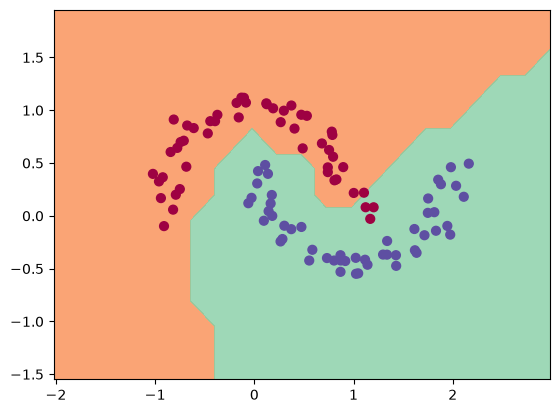

In [ ]:
# 决策边界可视化
h = 0.25
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Xmesh = np.c_[xx.ravel(), yy.ravel()]
inputs = [list(map(Value, xrow)) for xrow in Xmesh]
scores = list(map(model, inputs))
Z = np.array([s.data > 0 for s in scores])
Z = Z.reshape(xx.shape)

fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())